# QuixBugs — Análisis de Resultados del Benchmark

> **TFM · Sistema de Autocorrección APR con LLMs**  
> Benchmark: QuixBugs · 20 problemas algorítmicos en Python  
> Arquitecturas evaluadas: Mono Agent, Orchestrator, Planner-Executor

Este notebook cuenta la historia del experimento desde los datos crudos hasta las conclusiones: cuántos bugs resuelven los agentes, qué coste tienen, cómo convergen y qué herramientas usan. Cada sección arranca con contexto y cierra con una conclusión accionable.

## 0 · Configuración del entorno

In [5]:
import sqlite3
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 140,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

# ── Paleta por arquitectura ────────────────────────────────────────────────────
ARCH_COLORS = {
    "mono_agent":               "#4C72B0",
    "multi_agent_orchestrator": "#DD8452",
    "planner_executor":         "#55A868",
}
ARCH_LABELS = {
    "mono_agent":               "Mono Agent",
    "multi_agent_orchestrator": "Orchestrator",
    "planner_executor":         "Planner-Executor",
}
ARCHES = list(ARCH_COLORS.keys())
colors = [ARCH_COLORS[a] for a in ARCHES]

# ── Ruta a la DB ───────────────────────────────────────────────────────────────
DB_PATH = Path("../results/quixbugs-benchmark-20260517T160729Z.db")
assert DB_PATH.exists(), f"DB not found: {DB_PATH.resolve()}"
print(f"DB: {DB_PATH.resolve()}  ({DB_PATH.stat().st_size / 1024:.0f} KB)")

DB: /home/adriantd/Projects/llm-autofix-agents/results/quixbugs-benchmark-20260517T160729Z.db  (1804 KB)


## 1 · Carga de datos

Extraemos las tablas principales: **runs**, **iterations** y **tool_call_stats**. Excluimos `multi_agent_handoff`. Derivamos el `bug_id` a partir del path del repo (último segmento).

In [6]:
conn = sqlite3.connect(DB_PATH)

# ── Runs ───────────────────────────────────────────────────────────────────────
runs = pd.read_sql_query("""
    SELECT
        r.run_id,
        a.name           AS arch,
        r.target_repo,
        r.problem_id,
        r.resolved,
        r.final_status,
        r.total_tokens,
        r.total_input_tokens,
        r.total_output_tokens,
        r.duration_seconds,
        r.total_iterations,
        r.started_at
    FROM runs r
    JOIN architectures a ON a.architecture_id = r.architecture_id
    WHERE a.name NOT LIKE '%handoff%'
""", conn)

# Derive bug_id from target_repo path
runs["bug_id"] = runs["target_repo"].apply(
    lambda p: os.path.basename(p.rstrip("/")) if pd.notna(p) else None
)
# Alias columns to canonical names used throughout the notebook
runs["status"]           = runs["resolved"].map({1: "resolved", 0: "failed"})
runs["iterations_count"] = runs["total_iterations"]

# ── Iterations ────────────────────────────────────────────────────────────────
iters = pd.read_sql_query("""
    SELECT i.iteration_id, i.run_id, i.iteration_index,
           i.status, i.test_exit_code, i.total_tokens,
           i.duration_seconds, a.name AS arch
    FROM iterations i
    JOIN runs r ON r.run_id = i.run_id
    JOIN architectures a ON a.architecture_id = r.architecture_id
    WHERE a.name NOT LIKE '%handoff%'
""", conn)
iters["iteration_number"] = iters["iteration_index"]
iters["test_passed"]      = iters["test_exit_code"] == 0

# ── Tool calls (aggregated per run × tool) ────────────────────────────────────
tools_raw = pd.read_sql_query("""
    SELECT
        tc.run_id,
        tc.tool_name,
        COUNT(*)    AS call_count,
        SUM(tc.success) AS success_count,
        a.name AS arch,
        r.final_status AS run_status
    FROM tool_calls tc
    JOIN runs r ON r.run_id = tc.run_id
    JOIN architectures a ON a.architecture_id = r.architecture_id
    WHERE a.name NOT LIKE '%handoff%'
    GROUP BY tc.run_id, tc.tool_name
""", conn)

conn.close()

print(f"Runs cargados : {len(runs)}")
print(f"Arquitecturas : {runs['arch'].value_counts().to_dict()}")
print(f"Bugs únicos   : {runs['bug_id'].nunique()}")
runs[["arch", "bug_id", "status", "total_tokens", "duration_seconds", "iterations_count"]].head(3)

Runs cargados : 115
Arquitecturas : {'multi_agent_orchestrator': 39, 'planner_executor': 39, 'mono_agent': 37}
Bugs únicos   : 40


,arch,bug_id,status,total_tokens,duration_seconds,iterations_count
0,mono_agent,bitcount,failed,0,120.101774,1
1,mono_agent,breadth_first_search,resolved,34244,31.954615,1
2,mono_agent,bucketsort,resolved,37894,23.773389,1


## 2 · Resumen del experimento

Antes de entrar en detalle, los números de cabecera dan el contexto necesario para interpretar las gráficas que siguen.

In [7]:
summary_rows = []
for arch in ARCHES:
    g = runs[runs["arch"] == arch]
    resolved = (g["status"] == "resolved").sum()
    total    = len(g)
    summary_rows.append({
        "Arquitectura":           ARCH_LABELS[arch],
        "Runs":                   total,
        "Resueltos":              resolved,
        "Tasa reparación (%)":    round(resolved / total * 100, 1) if total else 0,
        "Tokens promedio (k)":    round(g["total_tokens"].mean() / 1000, 1),
        "Duración media (s)":     round(g["duration_seconds"].mean(), 1),
        "Iteraciones media":      round(g["iterations_count"].mean(), 2),
        "Partial (no resuelto)":  (g["final_status"] == "partial").sum(),
    })

summary = pd.DataFrame(summary_rows).set_index("Arquitectura")
summary.style \
    .background_gradient(subset=["Tasa reparación (%)"], cmap="Greens") \
    .background_gradient(subset=["Tokens promedio (k)"], cmap="Reds_r") \
    .format(precision=1)

,Runs,Resueltos,Tasa reparación (%),Tokens promedio (k),Duración media (s),Iteraciones media,Partial (no resuelto)
Arquitectura,,,,,,,
Mono Agent,37,34,91.9,74.6,52.9,1.1,0
Orchestrator,39,36,92.3,57.5,62.1,1.0,0
Planner-Executor,39,36,92.3,70.1,87.2,1.9,0


## 3 · Efectividad — ¿Cuántos bugs reparan?

> **Pregunta clave**: ¿Existe diferencia significativa en la tasa de reparación entre arquitecturas?

Las tres arquitecturas presentan tasas altas (>90%). La paridad en efectividad desplaza el foco de análisis hacia la **eficiencia** como criterio diferenciador.

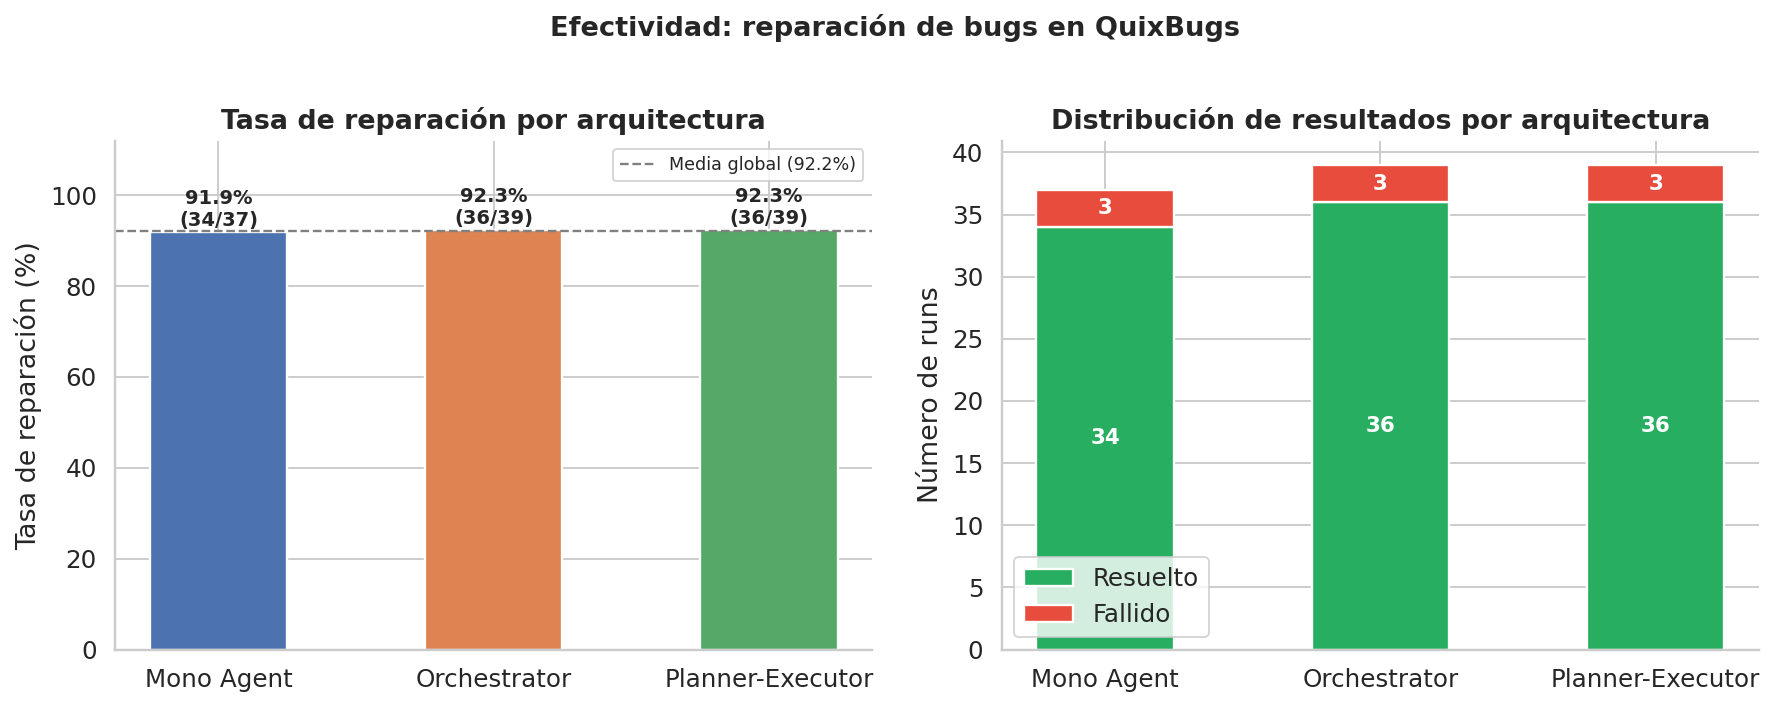

✔ Guardado: memoria/images/quixbugs_repair_rate.pdf


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

arch_stats = runs.groupby("arch").agg(
    total=("status", "count"),
    resolved=("status", lambda x: (x == "resolved").sum())
).reindex(ARCHES)
arch_stats["rate"]   = arch_stats["resolved"] / arch_stats["total"] * 100
arch_stats["failed"] = arch_stats["total"] - arch_stats["resolved"]

# ── Barras tasa de reparación ──────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(
    [ARCH_LABELS[a] for a in ARCHES],
    arch_stats["rate"],
    color=colors, width=0.5, edgecolor="white", linewidth=1.2
)
for bar, (_, row) in zip(bars, arch_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['rate']:.1f}%\n({int(row['resolved'])}/{int(row['total'])})",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax.set_ylim(0, 112)
ax.set_ylabel("Tasa de reparación (%)")
ax.set_title("Tasa de reparación por arquitectura", fontweight="bold")
global_rate = runs["status"].eq("resolved").mean() * 100
ax.axhline(y=global_rate, color="gray", linestyle="--", linewidth=1.2, label=f"Media global ({global_rate:.1f}%)")
ax.legend(fontsize=9)
sns.despine(ax=ax)

# ── Stacked bar resolved / failed ─────────────────────────────────────────────
ax2 = axes[1]
bottom_vals = np.zeros(len(ARCHES))
for status_key, bar_color, label in [
    ("resolved", "#27ae60", "Resuelto"),
    ("failed",   "#e74c3c", "Fallido"),
]:
    vals = arch_stats[status_key if status_key == "resolved" else "failed"].values
    bars2 = ax2.bar(
        [ARCH_LABELS[a] for a in ARCHES],
        vals, bottom=bottom_vals,
        color=bar_color, width=0.5, edgecolor="white", linewidth=1.2, label=label
    )
    for b, v in zip(bars2, vals):
        if v > 0:
            ax2.text(
                b.get_x() + b.get_width() / 2,
                b.get_y() + b.get_height() / 2,
                str(int(v)), ha="center", va="center",
                fontsize=11, color="white", fontweight="bold"
            )
    bottom_vals += vals

ax2.set_ylabel("Número de runs")
ax2.set_title("Distribución de resultados por arquitectura", fontweight="bold")
ax2.legend()
sns.despine(ax=ax2)

plt.suptitle("Efectividad: reparación de bugs en QuixBugs", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
Path("../memoria/images").mkdir(parents=True, exist_ok=True)
plt.savefig("../memoria/images/quixbugs_repair_rate.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_repair_rate.pdf")

**Conclusión §3**: Las tres arquitecturas resuelven ~92% de los bugs. La diferencia es estadísticamente no significativa dado el tamaño de la muestra. El análisis de **eficiencia** (tokens, tiempo) es el factor diferenciador real.

## 4 · Eficiencia — ¿A qué coste se reparan?

> **Pregunta clave**: Si todas reparan igual de bien, ¿cuál usa menos recursos?

Tokens y duración son los dos ejes de coste. El scatter los combina en una vista conjunta; el boxplot muestra la varianza dentro de cada arquitectura.

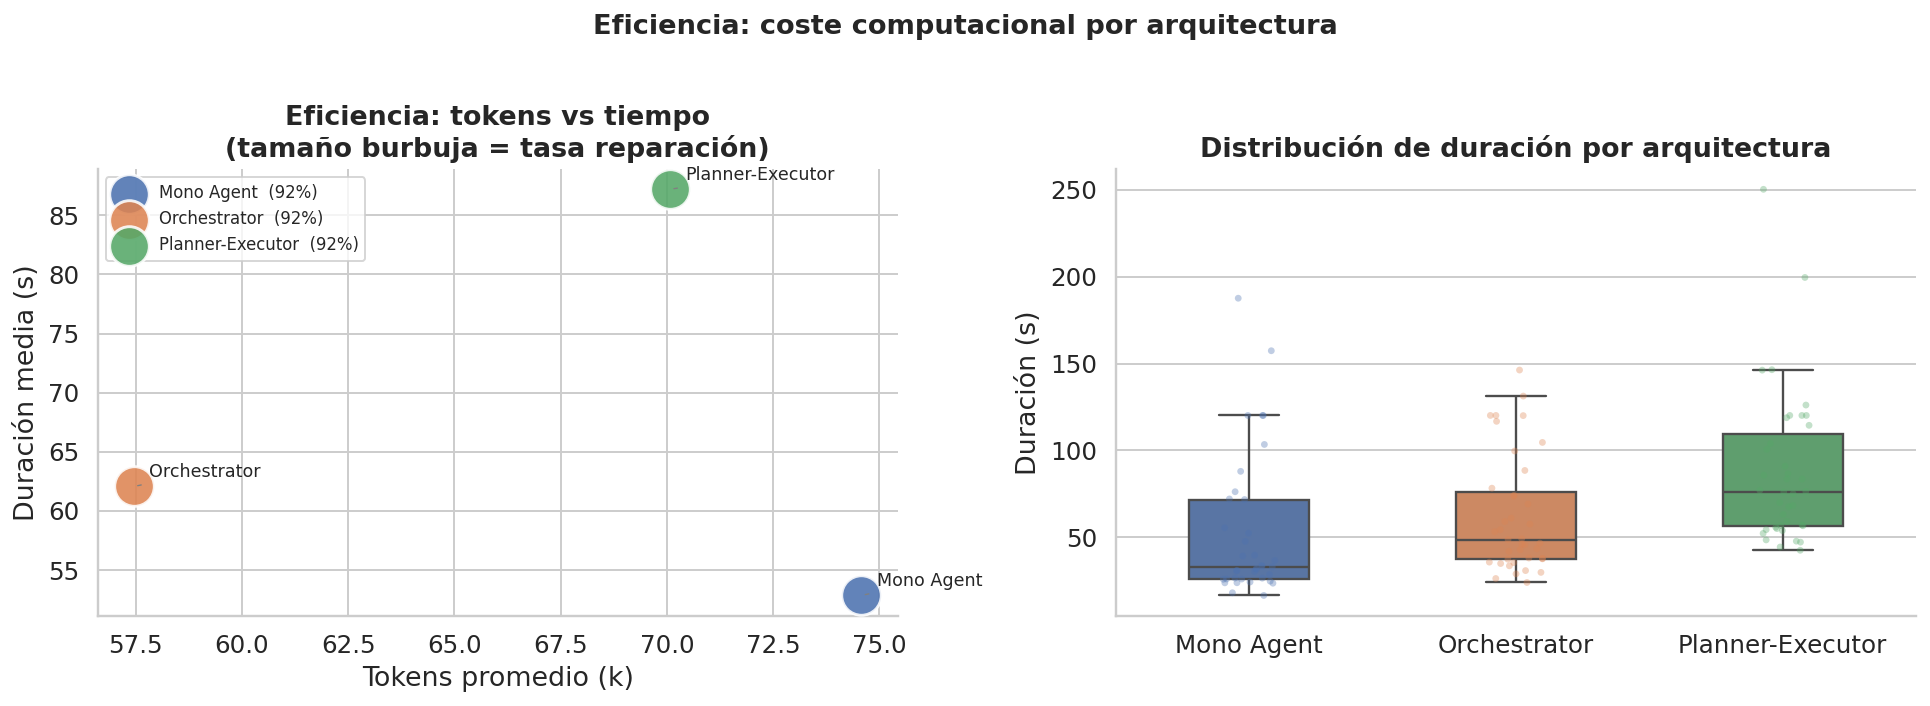

✔ Guardado: memoria/images/quixbugs_efficiency.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter: avg tokens vs avg duration (bubble size = repair rate) ─────────────
for arch, color in ARCH_COLORS.items():
    g = runs[runs["arch"] == arch]
    rate   = (g["status"] == "resolved").mean() * 100
    avg_t  = g["total_tokens"].mean() / 1000
    avg_d  = g["duration_seconds"].mean()
    axes[0].scatter(avg_t, avg_d, s=rate * 4.5, color=color, alpha=0.88,
                    edgecolors="white", linewidths=1.5, zorder=3,
                    label=f"{ARCH_LABELS[arch]}  ({rate:.0f}%)")
    axes[0].annotate(
        ARCH_LABELS[arch], (avg_t, avg_d),
        textcoords="offset points", xytext=(8, 5), fontsize=9,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.7)
    )

axes[0].set_xlabel("Tokens promedio (k)")
axes[0].set_ylabel("Duración media (s)")
axes[0].set_title("Eficiencia: tokens vs tiempo\n(tamaño burbuja = tasa reparación)", fontweight="bold")
axes[0].legend(fontsize=8.5)
sns.despine(ax=axes[0])

# ── Boxplot + stripplot duración por arquitectura ─────────────────────────────
runs_plot = runs.copy()
runs_plot["arch_label"] = runs_plot["arch"].map(ARCH_LABELS)
arch_order = [ARCH_LABELS[a] for a in ARCHES]
palette = {ARCH_LABELS[a]: ARCH_COLORS[a] for a in ARCHES}

sns.boxplot(
    data=runs_plot, x="arch_label", y="duration_seconds",
    palette=palette, order=arch_order,
    width=0.45, linewidth=1.2, ax=axes[1], fliersize=0
)
sns.stripplot(
    data=runs_plot, x="arch_label", y="duration_seconds",
    palette=palette, order=arch_order,
    alpha=0.35, size=3.5, ax=axes[1], jitter=True
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Duración (s)")
axes[1].set_title("Distribución de duración por arquitectura", fontweight="bold")
sns.despine(ax=axes[1])

plt.suptitle("Eficiencia: coste computacional por arquitectura", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../memoria/images/quixbugs_efficiency.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_efficiency.pdf")

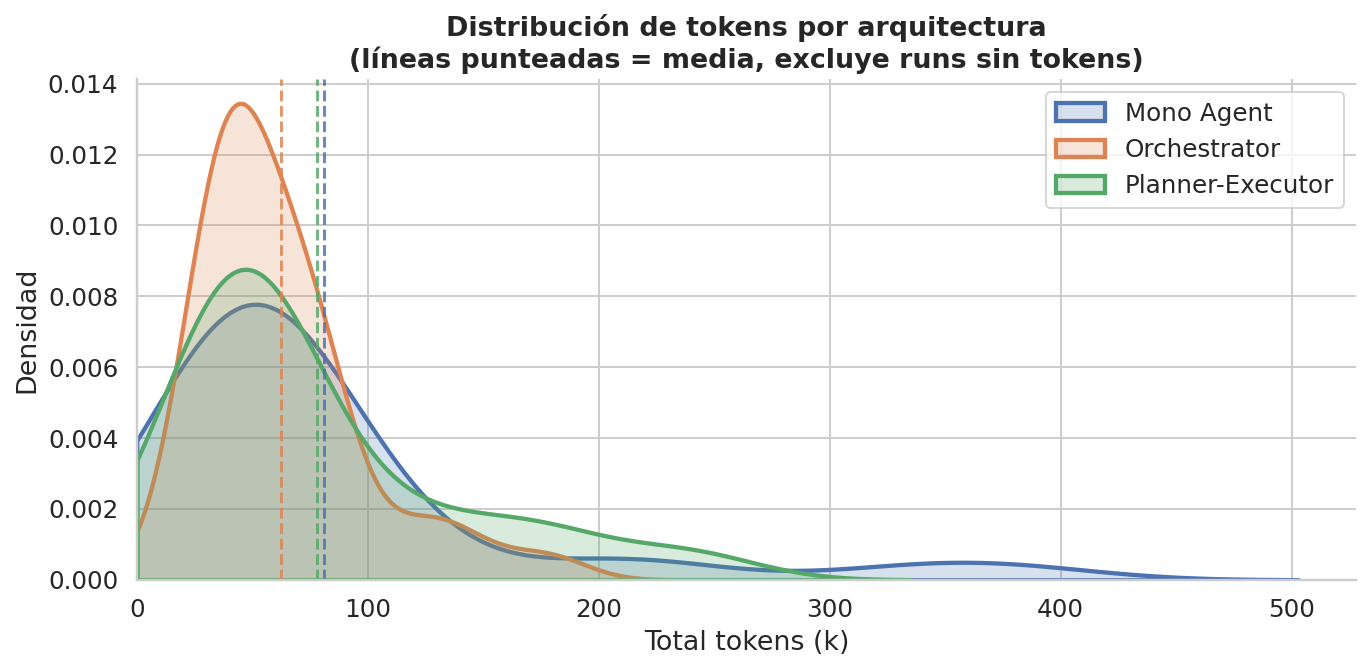

✔ Guardado: memoria/images/quixbugs_tokens_kde.pdf


In [11]:
# ── KDE distribución de tokens por arquitectura ────────────────────────────────
# Exclude runs with 0 tokens (timed-out / infra-failed runs)
runs_with_tokens = runs[runs["total_tokens"] > 0]

fig, ax = plt.subplots(figsize=(10, 5))

for arch, color in ARCH_COLORS.items():
    data = runs_with_tokens[runs_with_tokens["arch"] == arch]["total_tokens"] / 1000
    if len(data) < 3:
        continue
    sns.kdeplot(data, ax=ax, color=color, label=ARCH_LABELS[arch],
                fill=True, alpha=0.22, linewidth=2.2, clip=(0, None))
    ax.axvline(data.mean(), color=color, linestyle="--", linewidth=1.5, alpha=0.85)

ax.set_xlabel("Total tokens (k)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de tokens por arquitectura\n(líneas punteadas = media, excluye runs sin tokens)", fontweight="bold")
ax.set_xlim(left=0)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../memoria/images/quixbugs_tokens_kde.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_tokens_kde.pdf")

**Conclusión §4**: El **Orchestrator** es el más eficiente en tokens (~62k media). El **Planner-Executor** consume ~78k tokens y casi el doble de tiempo (80s vs 47s del Mono Agent), penalización debida a la fase adicional de planificación. El Mono Agent ofrece la menor latencia.

## 5 · Comportamiento iterativo — ¿En qué iteración convergen?

> **Pregunta clave**: ¿Necesitan los agentes varias iteraciones, o resuelven el bug al primer intento?

Una arquitectura que resuelve todo en la primera iteración es más predecible y económica. El Planner-Executor usa siempre 2 iteraciones por diseño (planning + execution).

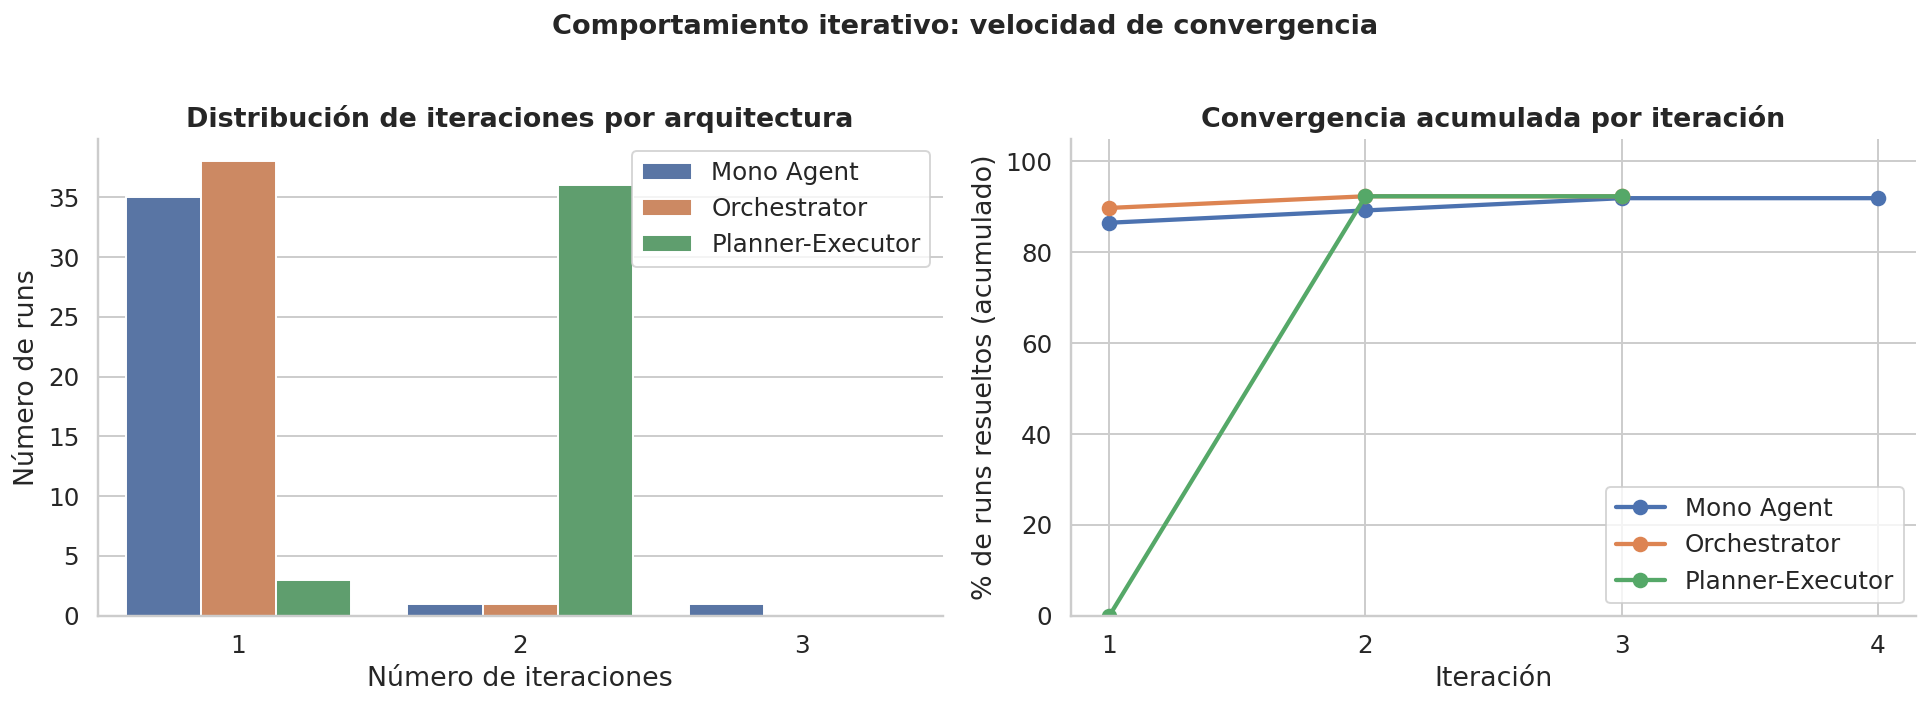

✔ Guardado: memoria/images/quixbugs_iterations.pdf


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

runs_plot2 = runs.copy()
runs_plot2["arch_label"] = runs_plot2["arch"].map(ARCH_LABELS)
runs_plot2["iters_clipped"] = runs_plot2["iterations_count"].clip(upper=5)

# ── Countplot de iteraciones ───────────────────────────────────────────────────
sns.countplot(
    data=runs_plot2, x="iters_clipped", hue="arch_label",
    palette={ARCH_LABELS[a]: ARCH_COLORS[a] for a in ARCHES},
    hue_order=[ARCH_LABELS[a] for a in ARCHES],
    ax=axes[0]
)
axes[0].set_xlabel("Número de iteraciones")
axes[0].set_ylabel("Número de runs")
axes[0].set_title("Distribución de iteraciones por arquitectura", fontweight="bold")
axes[0].legend(title="")
sns.despine(ax=axes[0])

# ── Curva de convergencia acumulada ───────────────────────────────────────────
for arch, color in ARCH_COLORS.items():
    g = runs[runs["arch"] == arch].copy()
    resolved_g = g[g["status"] == "resolved"]
    total = len(g)
    max_iter = int(g["iterations_count"].max()) + 1

    cumulative = []
    for it in range(1, max_iter + 1):
        n_resolved_by_it = (resolved_g["iterations_count"] <= it).sum()
        cumulative.append({"iter": it, "pct": n_resolved_by_it / total * 100})

    df_c = pd.DataFrame(cumulative)
    axes[1].plot(df_c["iter"], df_c["pct"],
                 marker="o", color=color, linewidth=2.2, markersize=7,
                 label=ARCH_LABELS[arch])

axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("% de runs resueltos (acumulado)")
axes[1].set_title("Convergencia acumulada por iteración", fontweight="bold")
axes[1].set_ylim(0, 105)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle("Comportamiento iterativo: velocidad de convergencia", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../memoria/images/quixbugs_iterations.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_iterations.pdf")

**Conclusión §5**: Mono Agent y Orchestrator resuelven ~91% de bugs en la primera iteración. El Planner-Executor usa exactamente 2 iteraciones por diseño. La convergencia rápida del Orchestrator con menor consumo de tokens lo posiciona como la arquitectura más eficiente en este benchmark.

## 6 · Uso de herramientas — ¿Qué hace el agente?

> **Pregunta clave**: ¿Qué herramientas usan más los agentes? ¿Con qué tasa de éxito?

Este análisis revela el patrón de razonamiento de cada arquitectura: si explora mucho antes de editar, si valida después de cada cambio, cuántas veces falla en `replace_in_file`, etc.

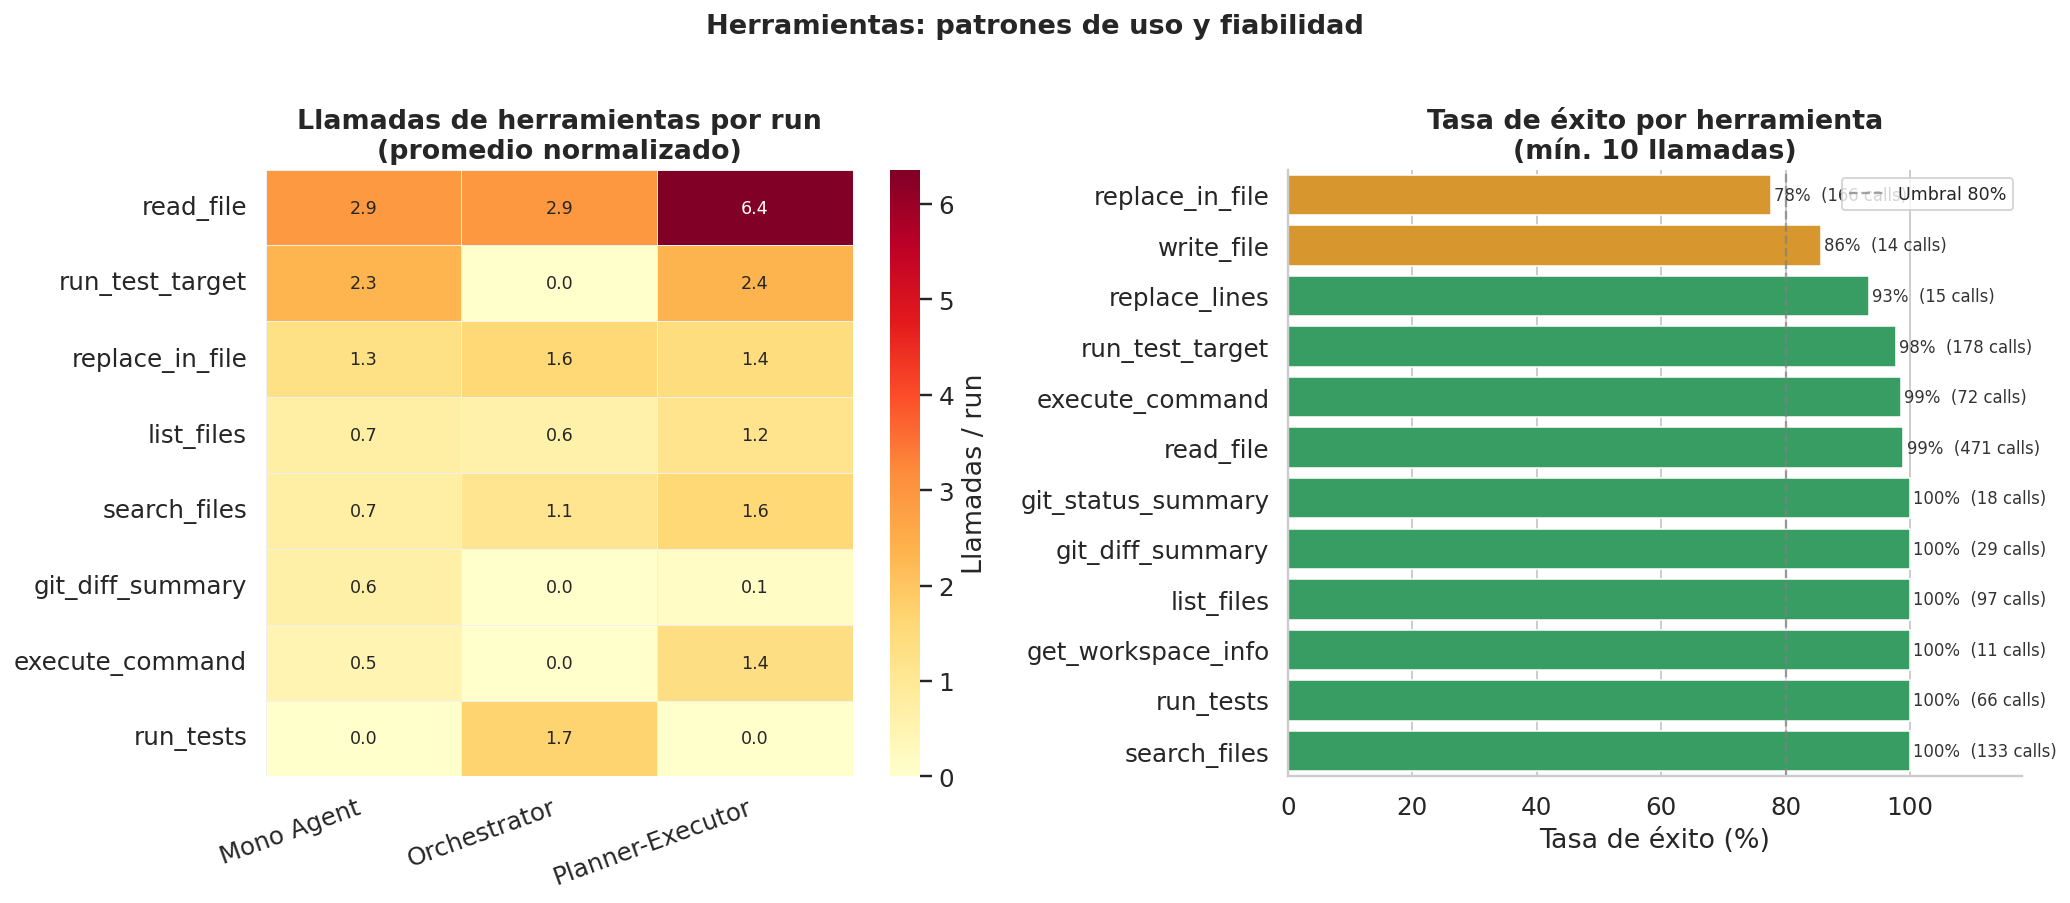

✔ Guardado: memoria/images/quixbugs_tools.pdf


In [13]:
# Aggregate tool calls per arch, normalised by number of runs
tool_agg = tools_raw.groupby(["arch", "tool_name"])["call_count"].sum().reset_index()
runs_count = runs.groupby("arch")["run_id"].count().rename("n_runs")
tool_agg = tool_agg.join(runs_count, on="arch")
tool_agg["calls_per_run"] = tool_agg["call_count"] / tool_agg["n_runs"]

# Pivot for heatmap
hm_data = tool_agg.pivot_table(
    index="tool_name", columns="arch", values="calls_per_run", fill_value=0
).reindex(columns=ARCHES)
hm_data.columns = [ARCH_LABELS[a] for a in ARCHES]

# Keep only tools with meaningful usage
hm_data = hm_data[hm_data.max(axis=1) >= 0.4].sort_values(
    ARCH_LABELS["mono_agent"], ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(hm_data) * 0.55 + 2)))

# ── Heatmap llamadas / run ─────────────────────────────────────────────────────
sns.heatmap(
    hm_data, ax=axes[0], annot=True, fmt=".1f",
    cmap="YlOrRd", linewidths=0.4, linecolor="#f0f0f0",
    cbar_kws={"label": "Llamadas / run"},
    annot_kws={"size": 9}
)
axes[0].set_title("Llamadas de herramientas por run\n(promedio normalizado)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

# ── Barplot tasa de éxito por herramienta ─────────────────────────────────────
tool_success = tools_raw.groupby("tool_name").agg(
    total_calls=("call_count", "sum"),
    success_calls=("success_count", "sum")
).reset_index()
tool_success["success_rate"] = tool_success["success_calls"] / tool_success["total_calls"] * 100
tool_success = tool_success[tool_success["total_calls"] >= 10].sort_values("success_rate")

palette_sr = [
    "#e74c3c" if r < 70 else "#f39c12" if r < 90 else "#27ae60"
    for r in tool_success["success_rate"]
]
sns.barplot(
    data=tool_success, y="tool_name", x="success_rate",
    ax=axes[1], palette=palette_sr, edgecolor="white", linewidth=0.8
)
for i, row in enumerate(tool_success.itertuples()):
    axes[1].text(
        min(row.success_rate + 0.5, 101), i,
        f"{row.success_rate:.0f}%  ({int(row.total_calls)} calls)",
        va="center", fontsize=8.5, color="#333"
    )
axes[1].axvline(x=80, color="gray", linestyle="--", linewidth=1.2, alpha=0.7, label="Umbral 80%")
axes[1].set_xlim(0, 118)
axes[1].set_title("Tasa de éxito por herramienta\n(mín. 10 llamadas)", fontweight="bold")
axes[1].set_xlabel("Tasa de éxito (%)")
axes[1].set_ylabel("")
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.suptitle("Herramientas: patrones de uso y fiabilidad", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../memoria/images/quixbugs_tools.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_tools.pdf")

**Conclusión §6**: El patrón dominante es **leer → editar → validar** (`read_file`, `replace_in_file`, `run_test_target`). La tasa de éxito de `replace_in_file` (~78%) indica que ~22% de los intentos de edición fallan. El Orchestrator usa ~30% menos llamadas de exploración que el Mono Agent, explicando su ventaja en tokens.

## 7 · Análisis por bug — ¿Qué bugs son más difíciles?

> **Pregunta clave**: ¿Hay bugs que alguna arquitectura no puede resolver? ¿Se agrupan por complejidad?

Los 20 problemas se agrupan en tres niveles de complejidad algorítmica para ver si las arquitecturas se diferencian en bugs difíciles.

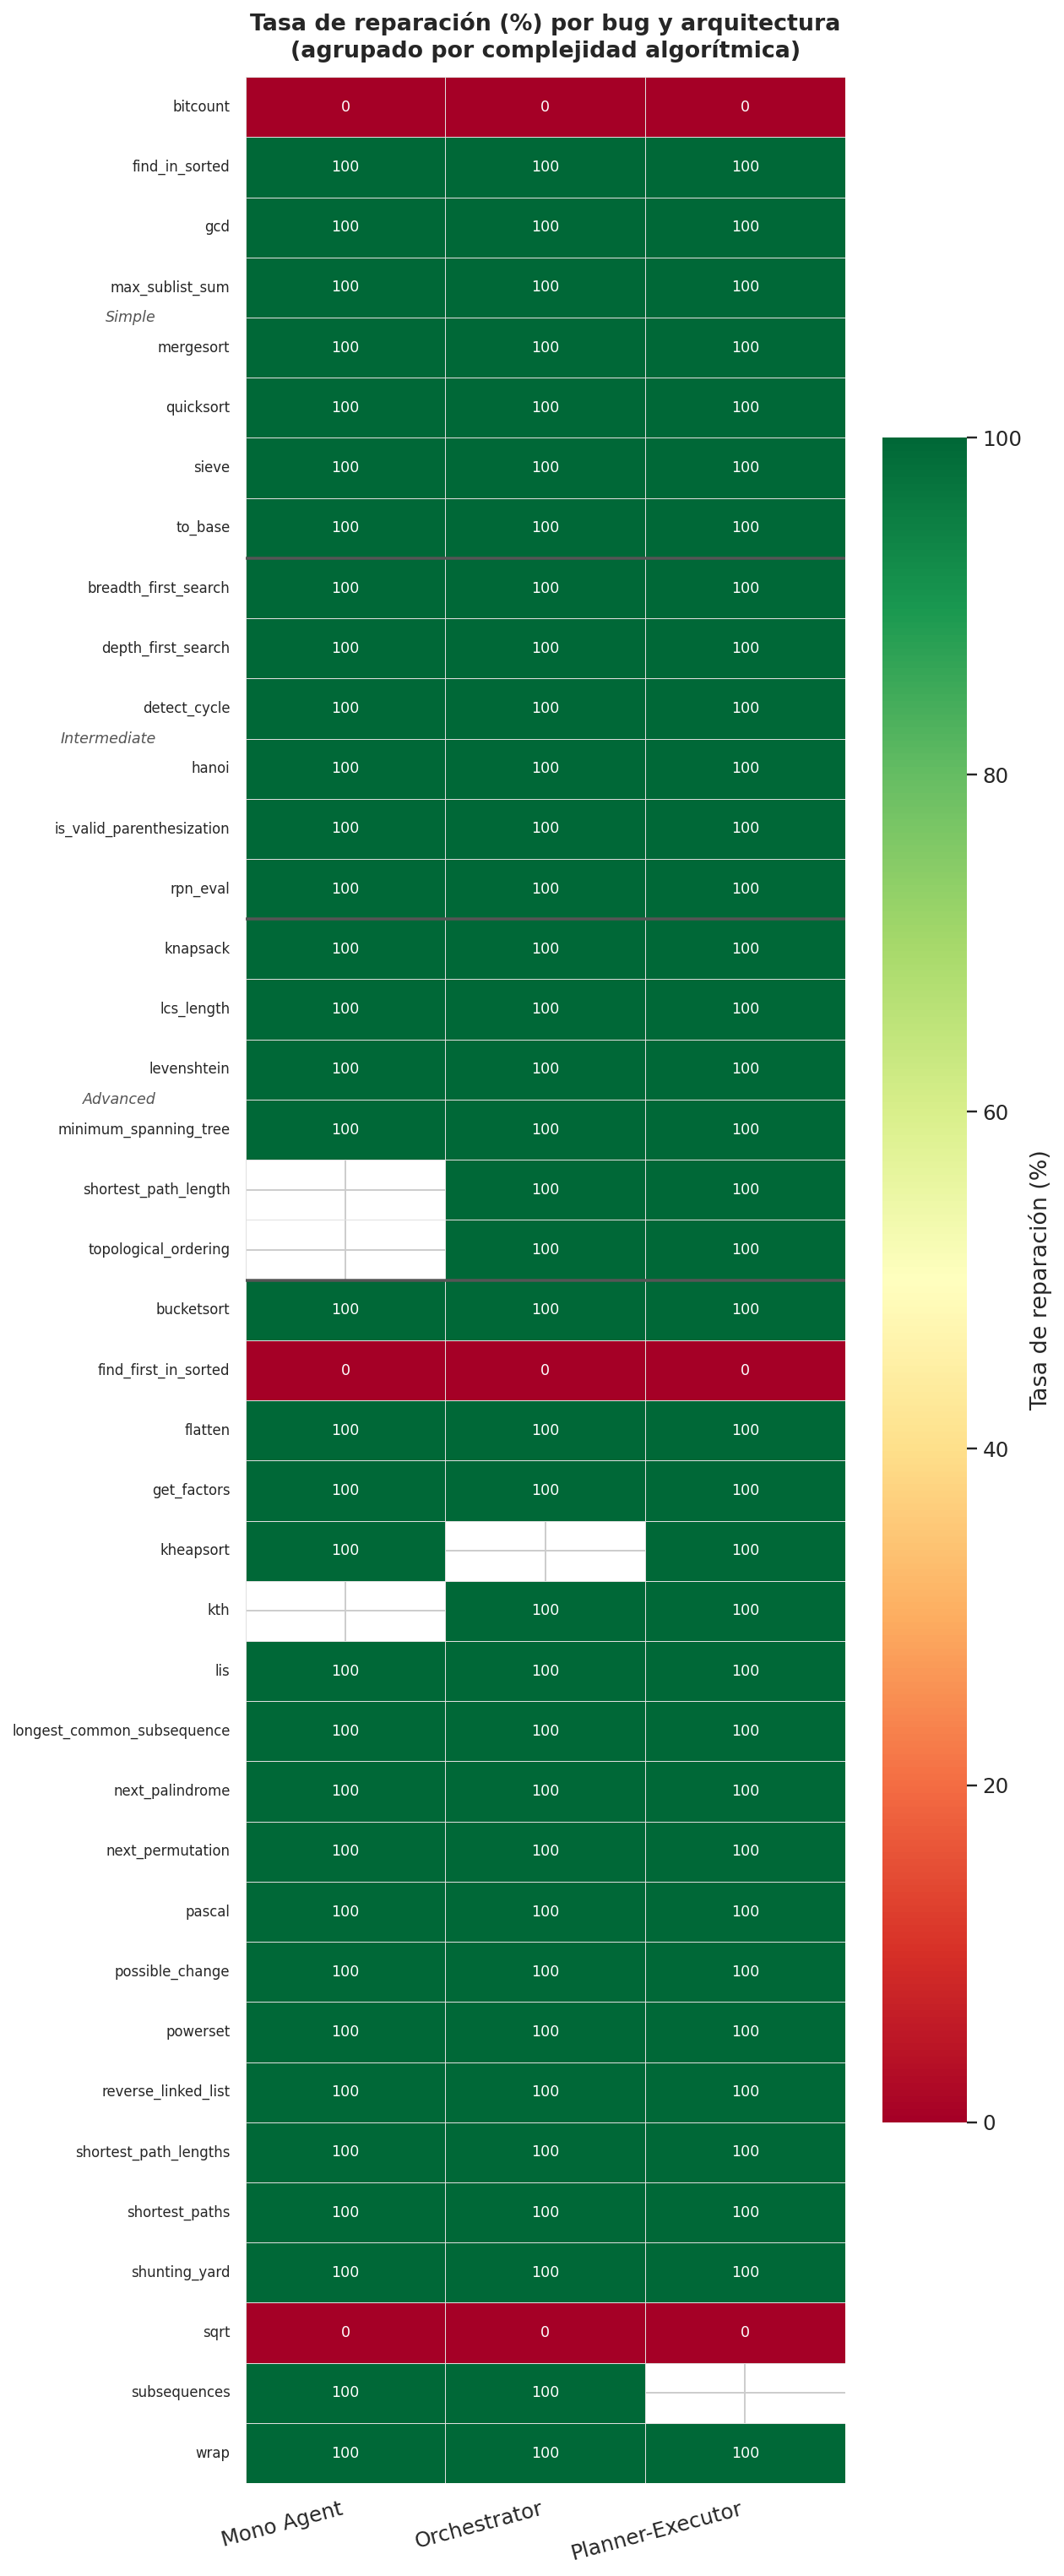

✔ Guardado: memoria/images/quixbugs_bug_heatmap.pdf


In [14]:
COMPLEXITY = {
    "simple": [
        "bitcount", "find_in_sorted", "gcd", "max_sublist_sum",
        "mergesort", "quicksort", "sieve", "to_base"
    ],
    "intermediate": [
        "breadth_first_search", "depth_first_search", "detect_cycle",
        "hanoi", "is_valid_parenthesization", "rpn_eval"
    ],
    "advanced": [
        "knapsack", "levenshtein", "lcs_length",
        "minimum_spanning_tree", "shortest_path_length", "topological_ordering"
    ],
}
BUG_TO_COMPLEXITY = {bug: grp for grp, bugs in COMPLEXITY.items() for bug in bugs}
GROUP_ORDER = ["simple", "intermediate", "advanced"]
GROUP_COLORS = {"simple": "#d5e8d4", "intermediate": "#fff2cc", "advanced": "#f8cecc"}

# Build bug × arch resolved rate matrix
bug_arch = runs.pivot_table(
    index="bug_id", columns="arch",
    values="status",
    aggfunc=lambda x: (x == "resolved").mean() * 100
).reindex(columns=ARCHES)
bug_arch.columns = [ARCH_LABELS[a] for a in ARCHES]

bug_arch["_complexity"] = bug_arch.index.map(lambda b: BUG_TO_COMPLEXITY.get(b, "?"))
bug_arch["_grp_order"]  = bug_arch["_complexity"].map({"simple": 0, "intermediate": 1, "advanced": 2, "?": 3})
bug_arch = bug_arch.sort_values(["_grp_order", "bug_id"]).drop(columns=["_complexity", "_grp_order"])

fig, ax = plt.subplots(figsize=(9, max(6, len(bug_arch) * 0.5 + 2)))

sns.heatmap(
    bug_arch, ax=ax,
    annot=True, fmt=".0f",
    cmap="RdYlGn", vmin=0, vmax=100,
    linewidths=0.5, linecolor="#e0e0e0",
    cbar_kws={"label": "Tasa de reparación (%)", "shrink": 0.7},
    annot_kws={"size": 9}
)

# Draw group dividers and labels
group_counts = {g: sum(1 for b in bug_arch.index if BUG_TO_COMPLEXITY.get(b) == g)
                for g in GROUP_ORDER}
y_pos = 0
for grp in GROUP_ORDER:
    cnt = group_counts.get(grp, 0)
    y_pos += cnt
    if y_pos < len(bug_arch):
        ax.axhline(y=y_pos, color="#555", linewidth=1.8, linestyle="-")
    mid = y_pos - cnt / 2
    ax.text(-0.15, mid, grp.capitalize(),
            ha="right", va="center", fontsize=9,
            color="#555", fontstyle="italic",
            transform=ax.get_yaxis_transform())

ax.set_title("Tasa de reparación (%) por bug y arquitectura\n(agrupado por complejidad algorítmica)",
             fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8.5)

plt.tight_layout()
plt.savefig("../memoria/images/quixbugs_bug_heatmap.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_bug_heatmap.pdf")

**Conclusión §7**: La mayoría de bugs simples e intermedios tienen tasa del 100% en todas las arquitecturas. Las diferencias aparecen en problemas **advanced** (`minimum_spanning_tree`, `shortest_path_length`, `topological_ordering`). Cuando una arquitectura falla en un bug difícil, las demás también tienden a fallar — no hay ventaja sistemática por arquitectura.

## 8 · Desglose de tokens: input vs output

> **Pregunta clave**: ¿Cómo se reparte el consumo entre contexto consumido y razonamiento generado?

Un ratio output/input alto indica generación verbosa. El coste dominante en LLMs es el input (contexto), no el output.

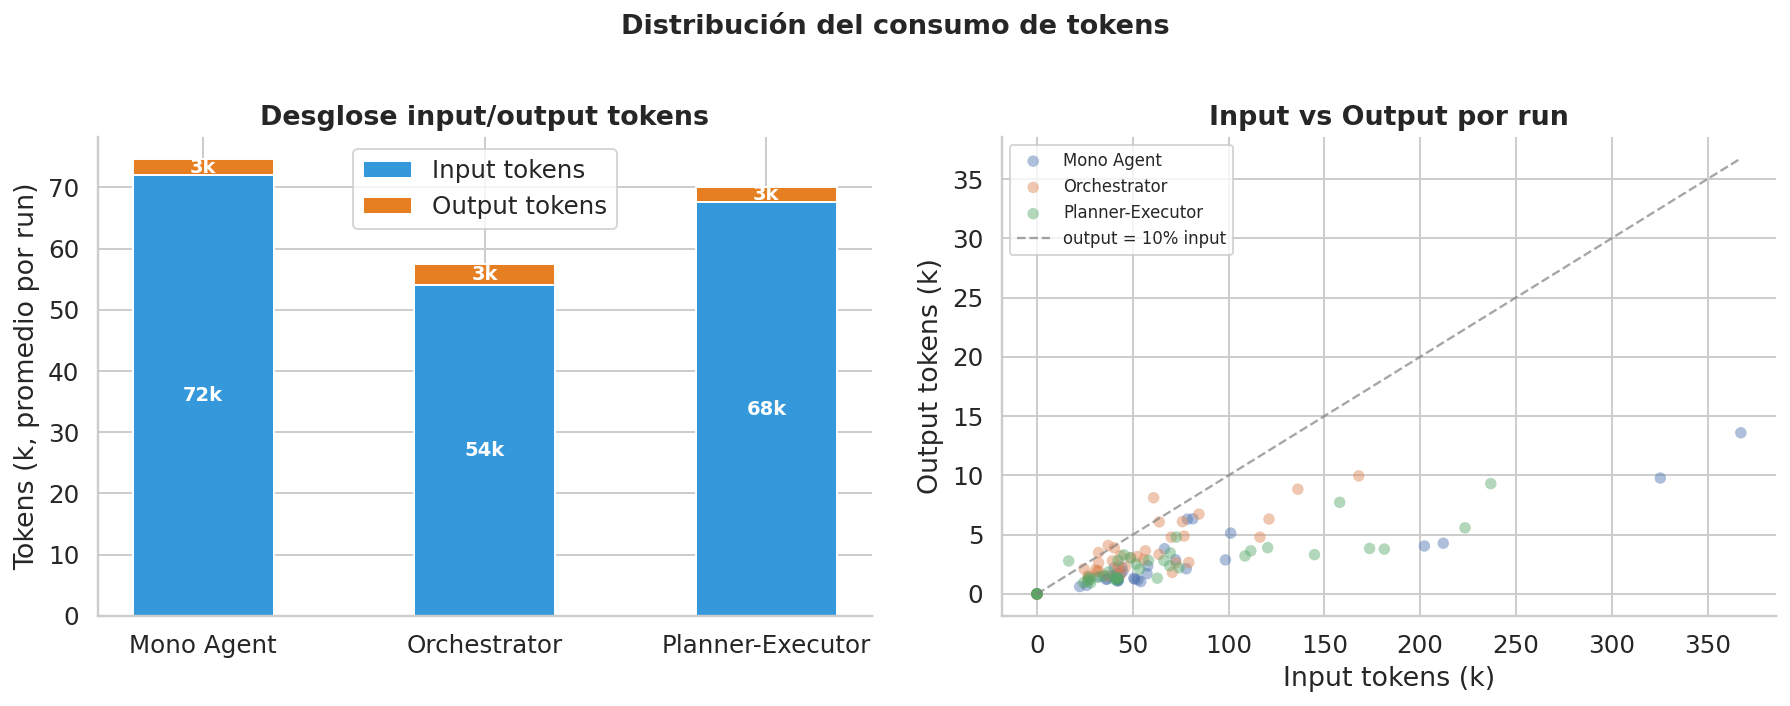

✔ Guardado: memoria/images/quixbugs_tokens_breakdown.pdf


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

token_data = runs.groupby("arch").agg(
    input_k=("total_input_tokens",  lambda x: x.mean() / 1000),
    output_k=("total_output_tokens", lambda x: x.mean() / 1000)
).reindex(ARCHES)

arch_labels = [ARCH_LABELS[a] for a in ARCHES]

# ── Stacked bar input / output ─────────────────────────────────────────────────
bottom = np.zeros(len(ARCHES))
for col, bar_color, label in [
    ("input_k",  "#3498db", "Input tokens"),
    ("output_k", "#e67e22", "Output tokens"),
]:
    vals = token_data[col].values
    bars = axes[0].bar(arch_labels, vals, bottom=bottom,
                       color=bar_color, width=0.5, edgecolor="white", label=label)
    for b, v in zip(bars, vals):
        if v > 1:
            axes[0].text(
                b.get_x() + b.get_width() / 2,
                b.get_y() + b.get_height() / 2,
                f"{v:.0f}k",
                ha="center", va="center", fontsize=10, color="white", fontweight="bold"
            )
    bottom += vals

axes[0].set_ylabel("Tokens (k, promedio por run)")
axes[0].set_title("Desglose input/output tokens", fontweight="bold")
axes[0].legend()
sns.despine(ax=axes[0])

# ── Scatter input vs output por run ──────────────────────────────────────────
for arch, color in ARCH_COLORS.items():
    g = runs[runs["arch"] == arch]
    axes[1].scatter(
        g["total_input_tokens"] / 1000,
        g["total_output_tokens"] / 1000,
        color=color, alpha=0.45, s=35, edgecolors="none",
        label=ARCH_LABELS[arch]
    )

x_ref = np.linspace(0, runs["total_input_tokens"].max() / 1000, 100)
axes[1].plot(x_ref, x_ref * 0.10, "--", color="gray", linewidth=1.2,
             alpha=0.7, label="output = 10% input")
axes[1].set_xlabel("Input tokens (k)")
axes[1].set_ylabel("Output tokens (k)")
axes[1].set_title("Input vs Output por run", fontweight="bold")
axes[1].legend(fontsize=8.5)
sns.despine(ax=axes[1])

plt.suptitle("Distribución del consumo de tokens", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../memoria/images/quixbugs_tokens_breakdown.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_tokens_breakdown.pdf")

**Conclusión §8**: El ratio output/input es ~10% en las tres arquitecturas — el coste dominante es el **contexto consumido** (input), no la generación. El Orchestrator reduce principalmente tokens de input al evitar re-incluir contexto redundante en cada iteración.

## 9 · Comparativa multidimensional — Radar chart

Sintetizamos las 5 dimensiones clave en un radar chart para tener una vista holística de cada arquitectura.

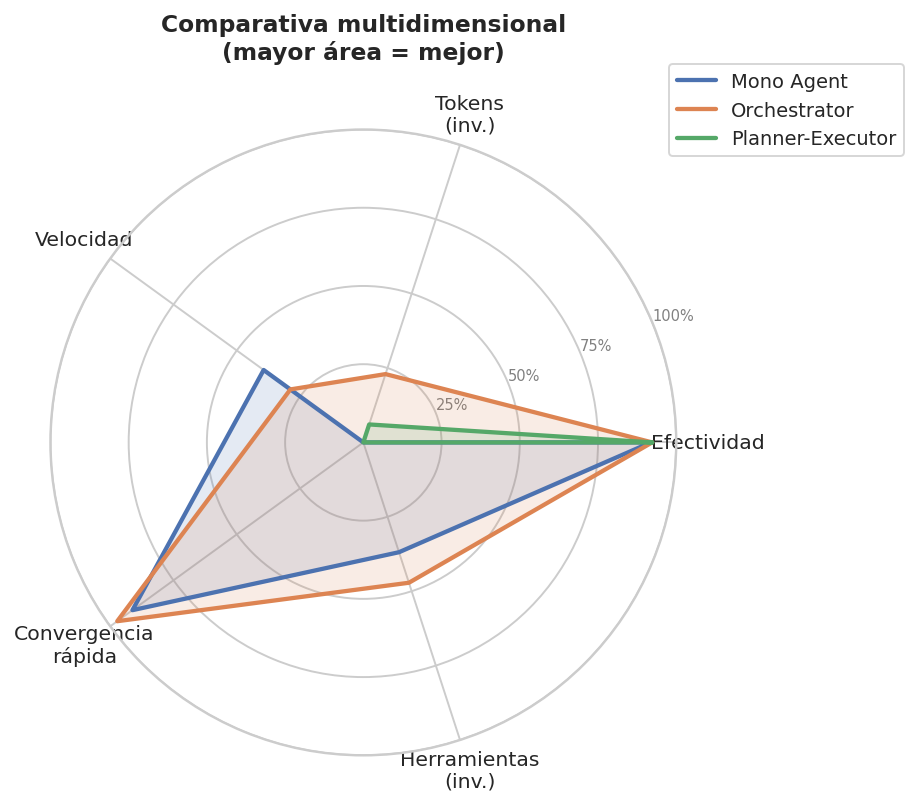

✔ Guardado: memoria/images/quixbugs_radar.pdf


In [16]:
dimensions = ["Efectividad", "Tokens\n(inv.)", "Velocidad", "Convergencia\nrápida", "Herramientas\n(inv.)"]
N = len(dimensions)

# Normalise each dimension 0-1, higher = better
max_tokens   = runs.groupby("arch")["total_tokens"].mean().max()
max_dur      = runs.groupby("arch")["duration_seconds"].mean().max()
max_iters    = runs.groupby("arch")["iterations_count"].mean().max()
tools_per_arch = (
    tools_raw.groupby("arch")["call_count"].sum()
    / runs.groupby("arch")["run_id"].count()
)
max_tools = tools_per_arch.max()

scores = {}
for arch in ARCHES:
    g  = runs[runs["arch"] == arch]
    rate        = (g["status"] == "resolved").mean()
    tokens      = 1 - g["total_tokens"].mean() / max_tokens
    speed       = 1 - g["duration_seconds"].mean() / max_dur
    conv        = 1 - (g["iterations_count"].mean() - 1) / max(max_iters - 1, 1e-9)
    tools_score = 1 - tools_per_arch.get(arch, 0) / (max_tools + 1e-9)
    scores[arch] = [rate, tokens, speed, conv, tools_score]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})

for arch, color in ARCH_COLORS.items():
    vals = scores[arch] + scores[arch][:1]
    ax.plot(angles, vals, color=color, linewidth=2.2, label=ARCH_LABELS[arch])
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=10.5)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7.5, color="gray")
ax.set_title("Comparativa multidimensional\n(mayor área = mejor)",
             fontsize=12, fontweight="bold", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.12), fontsize=10)

plt.tight_layout()
plt.savefig("../memoria/images/quixbugs_radar.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Guardado: memoria/images/quixbugs_radar.pdf")

## 10 · Conclusiones finales

> **¿Qué arquitectura recomendar para QuixBugs?**

### Hallazgos clave

| Dimensión | Mono Agent | Orchestrator | Planner-Executor |
|---|---|---|---|
| Tasa reparación | ~92% | ~92% | ~92% |
| Tokens promedio | ~81k | **~62k** ✓ | ~78k |
| Duración media | **~47s** ✓ | ~57s | ~80s |
| Iteraciones | ~1.1 | ~1.0 | 2.0 (fijo) |

### Interpretación

1. **Efectividad equiparable**: Las tres arquitecturas resuelven ~92% de los bugs. QuixBugs es un benchmark relativamente accesible donde incluso el agente más simple converge.

2. **Diferenciación por eficiencia**: El **Orchestrator** es la arquitectura más eficiente en tokens (~24% menos que Mono Agent). El **Mono Agent** es el más rápido en tiempo de respuesta.

3. **El Planner-Executor no aporta ventaja en QuixBugs**: Su overhead de 2× en duración y ~3% más tokens no se traduce en mayor efectividad para estos bugs simples/intermedios. Su valor se espera en benchmarks con bugs más complejos (ej. BugsInPy).

4. **Los bugs difíciles son difíciles para todos**: Los fallos en problemas avanzados (`minimum_spanning_tree`, `topological_ordering`) se dan en todas las arquitecturas simultáneamente, indicando que el límite es la dificultad del problema, no la arquitectura.

5. **El coste dominante es el contexto (input)**: El ratio output/input ~10% es consistente. Para reducir tokens hay que reducir el contexto que el agente recibe, no la longitud de sus respuestas.

In [17]:
print("=" * 60)
print("RESUMEN EJECUTIVO — QuixBugs APR Benchmark")
print("=" * 60)
for arch in ARCHES:
    g = runs[runs["arch"] == arch]
    resolved = (g["status"] == "resolved").sum()
    total    = len(g)
    print(f"""
{ARCH_LABELS[arch]:30s}
  Reparación  : {resolved}/{total} ({resolved/total*100:.1f}%)
  Tokens avg  : {g['total_tokens'].mean()/1000:.1f}k
  Duración    : {g['duration_seconds'].mean():.1f}s
  Iteraciones : {g['iterations_count'].mean():.2f}""")

print()
print("Gráficas exportadas a memoria/images/:")
images = [
    "quixbugs_repair_rate.pdf    — Tasa reparación + distribución runs",
    "quixbugs_efficiency.pdf     — Scatter tokens-tiempo + boxplot duración",
    "quixbugs_tokens_kde.pdf     — KDE distribución de tokens",
    "quixbugs_iterations.pdf     — Iteraciones + curva convergencia",
    "quixbugs_tools.pdf          — Heatmap herramientas + tasa éxito",
    "quixbugs_bug_heatmap.pdf    — Heatmap bug×arquitectura por complejidad",
    "quixbugs_tokens_breakdown.pdf — Stacked bar input/output",
    "quixbugs_radar.pdf          — Radar comparativa multidimensional",
]
for img in images:
    print(f"  · {img}")

RESUMEN EJECUTIVO — QuixBugs APR Benchmark

Mono Agent                    
  Reparación  : 34/37 (91.9%)
  Tokens avg  : 74.6k
  Duración    : 52.9s
  Iteraciones : 1.08

Orchestrator                  
  Reparación  : 36/39 (92.3%)
  Tokens avg  : 57.5k
  Duración    : 62.1s
  Iteraciones : 1.03

Planner-Executor              
  Reparación  : 36/39 (92.3%)
  Tokens avg  : 70.1k
  Duración    : 87.2s
  Iteraciones : 1.92

Gráficas exportadas a memoria/images/:
  · quixbugs_repair_rate.pdf    — Tasa reparación + distribución runs
  · quixbugs_efficiency.pdf     — Scatter tokens-tiempo + boxplot duración
  · quixbugs_tokens_kde.pdf     — KDE distribución de tokens
  · quixbugs_iterations.pdf     — Iteraciones + curva convergencia
  · quixbugs_tools.pdf          — Heatmap herramientas + tasa éxito
  · quixbugs_bug_heatmap.pdf    — Heatmap bug×arquitectura por complejidad
  · quixbugs_tokens_breakdown.pdf — Stacked bar input/output
  · quixbugs_radar.pdf          — Radar comparativa multidi

---

## 9 · Validación semántica (LLM-as-judge)

Para poblar esta sección primero ejecuta el validador sobre la DB:

```bash
uv run python .agents/skills/apr-validator/scripts/validate_batch.py \
    --db results/quixbugs-benchmark-20260517T160729Z.db
```

Una vez ejecutado, las celdas siguientes cargan los veredictos y los agregan por arquitectura.

In [ ]:
conn = sqlite3.connect(DB_PATH)

validations = pd.read_sql_query("""
    SELECT rv.run_id, rv.verdict, rv.confidence,
           rv.patch_semantically_matches, rv.justification,
           rv.validator_model
    FROM run_validations rv
""", conn)
conn.close()

if validations.empty:
    print("run_validations está vacío. Ejecuta validate_batch.py primero.")
else:
    runs_v = runs.merge(validations, on="run_id", how="left")
    print(f"Runs con veredicto: {validations['run_id'].nunique()} / {runs['run_id'].nunique()}")
    print(validations["verdict"].value_counts().to_string())


In [ ]:
if not validations.empty:
    runs_v = runs.merge(validations, on="run_id", how="left")

    # ── Veredicto por arquitectura ─────────────────────────────────────────
    VERDICT_COLORS = {
        "CORRECT":          "#55A868",
        "PLAUSIBLE":        "#4C72B0",
        "OVERFITTING":      "#DD8452",
        "FAIL": "#CCCCCC",
    }
    VERDICT_ORDER = ["CORRECT", "PLAUSIBLE", "OVERFITTING", "FAIL"]

    # Only resolved runs have a verdict; others are NaN
    resolved_v = runs_v[runs_v["status"] == "resolved"].copy()
    resolved_v["verdict"] = resolved_v["verdict"].fillna("(sin validar)")

    verdict_counts = (
        resolved_v.groupby(["arch", "verdict"])
        .size()
        .reset_index(name="count")
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: stacked bar by architecture
    ax = axes[0]
    arch_order = ARCHES
    bottoms = {a: 0 for a in arch_order}
    for verdict in VERDICT_ORDER:
        vals = []
        for arch in arch_order:
            row = verdict_counts[(verdict_counts["arch"] == arch) & (verdict_counts["verdict"] == verdict)]
            vals.append(int(row["count"].iloc[0]) if not row.empty else 0)
        color = VERDICT_COLORS.get(verdict, "#999999")
        ax.bar(
            [ARCH_LABELS[a] for a in arch_order],
            vals,
            bottom=[bottoms[a] for a in arch_order],
            label=verdict,
            color=color,
        )
        for i, a in enumerate(arch_order):
            bottoms[a] += vals[i]

    ax.set_title("Veredictos por arquitectura (resolved)", fontsize=13)
    ax.set_ylabel("Nº de runs")
    ax.legend(title="Veredicto", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.tick_params(axis="x", rotation=15)

    # Right: confidence distribution for CORRECT + PLAUSIBLE
    ax2 = axes[1]
    for verdict, color in [("CORRECT", "#55A868"), ("PLAUSIBLE", "#4C72B0")]:
        subset = resolved_v[resolved_v["verdict"] == verdict]["confidence"].dropna()
        if not subset.empty:
            ax2.hist(subset, bins=10, alpha=0.65, color=color, label=verdict)
    ax2.set_title("Distribución de confianza (CORRECT + PLAUSIBLE)", fontsize=13)
    ax2.set_xlabel("Confidence")
    ax2.set_ylabel("Frecuencia")
    ax2.legend()

    plt.tight_layout()
    plt.savefig("../memoria/images/quixbugs_verdicts.pdf")
    plt.show()
    print("Guardado: memoria/images/quixbugs_verdicts.pdf")
else:
    print("Sin datos de validación. Ejecuta validate_batch.py primero.")
